# Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
sns.set_theme(style= "whitegrid")

## Loading the Dataset

In [4]:
df = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Prediction (Survived),Prediction (Survived) (Confidence)
0,892,0,3,"Kelly, Mr. James",male,34.50000,0,0,330911,7.8292,NaN,Q,0,0.98
1,895,0,3,"Wirz, Mr. Albert",male,27.00000,0,0,315154,8.6625,NaN,S,0,0.99
2,899,0,2,"Caldwell, Mr. Albert Francis",male,26.00000,1,1,248738,29.0000,NaN,S,0,0.96
3,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.00000,0,0,2657,7.2292,NaN,C,1,0.98
4,901,0,3,"Davies, Mr. John Samuel",male,21.00000,2,0,A/4 48871,24.1500,NaN,S,0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,1284,0,3,"Abbott, Master. Eugene Joseph",male,13.00000,0,2,C.A. 2673,20.2500,NaN,S,0,0.99
80,1285,0,2,"Gilbert, Mr. William",male,47.00000,0,0,C.A. 30769,10.5000,NaN,S,0,0.94
81,1288,0,3,"Colbert, Mr. Patrick",male,24.00000,0,0,371109,7.2500,NaN,Q,0,0.95
82,1295,0,1,"Carrau, Mr. Jose Pedro",male,17.00000,0,0,113059,47.1000,NaN,S,0,0.98


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   PassengerId                         84 non-null     int64  
 1   Survived                            84 non-null     int64  
 2   Pclass                              84 non-null     int64  
 3   Name                                84 non-null     str    
 4   Sex                                 84 non-null     float64
 5   Age                                 84 non-null     float64
 6   SibSp                               84 non-null     int64  
 7   Parch                               84 non-null     int64  
 8   Ticket                              84 non-null     str    
 9   Fare                                84 non-null     float64
 10  Cabin                               12 non-null     str    
 11  Embarked                            0 non-null      float6

In [14]:
print(df['Survived'].value_counts())

Survived
0    56
1    28
Name: count, dtype: int64


In [15]:
print(df.groupby('Sex')[['Survived']].mean())

     Survived
Sex          
0.0  0.333333


## Survival rate by Pclass

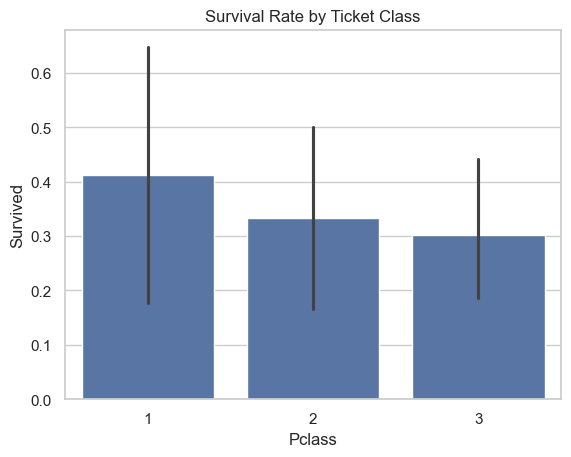

In [16]:
sns.barplot(x= 'Pclass', y='Survived', data= df )
plt.title("Survival Rate by Ticket Class")
plt.show()

## Wealth Check

In [17]:
print(df.groupby('Pclass')[['Survived']].mean())

        Survived
Pclass          
1       0.411765
2       0.333333
3       0.302326


## The "Age" Histogram

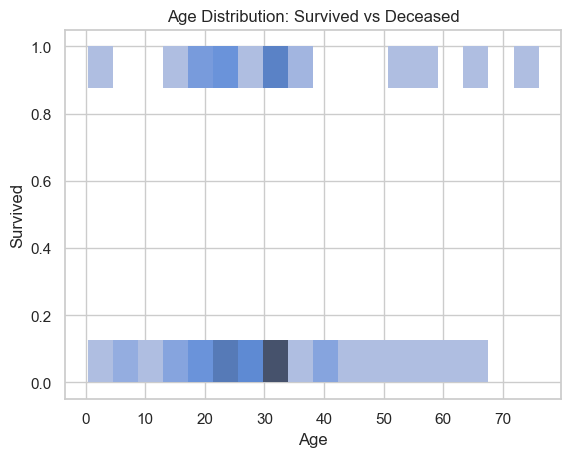

In [18]:
sns.histplot(data= df, x= 'Age', y= "Survived", kde= True)
plt.title("Age Distribution: Survived vs Deceased")
plt.show()


## Checking if there is a Wealth Gap

In [19]:
print(df.pivot_table("Survived", index= "Sex", columns= "Pclass"))

Pclass         1         2         3
Sex                                 
0.0     0.411765  0.333333  0.302326


## Handling missing values


In [20]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Prediction (Survived),Prediction (Survived) (Confidence)
0,892,0,3,"Kelly, Mr. James",0.0,34.50000,0,0,330911,7.8292,NaN,NaN,0,0.98
1,895,0,3,"Wirz, Mr. Albert",0.0,27.00000,0,0,315154,8.6625,NaN,NaN,0,0.99
2,899,0,2,"Caldwell, Mr. Albert Francis",0.0,26.00000,1,1,248738,29.0000,NaN,NaN,0,0.96
3,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",0.0,18.00000,0,0,2657,7.2292,NaN,NaN,1,0.98
4,901,0,3,"Davies, Mr. John Samuel",0.0,21.00000,2,0,A/4 48871,24.1500,NaN,NaN,0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,1284,0,3,"Abbott, Master. Eugene Joseph",0.0,13.00000,0,2,C.A. 2673,20.2500,NaN,NaN,0,0.99
80,1285,0,2,"Gilbert, Mr. William",0.0,47.00000,0,0,C.A. 30769,10.5000,NaN,NaN,0,0.94
81,1288,0,3,"Colbert, Mr. Patrick",0.0,24.00000,0,0,371109,7.2500,NaN,NaN,0,0.95
82,1295,0,1,"Carrau, Mr. Jose Pedro",0.0,17.00000,0,0,113059,47.1000,NaN,NaN,0,0.98


## Converting categories Into numbers (Encoding)

In [21]:
df['Sex'] = df['Sex'].map({'female' : 0, 'male' : 1 })
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Prediction (Survived),Prediction (Survived) (Confidence)
0,892,0,3,"Kelly, Mr. James",NaN,34.50000,0,0,330911,7.8292,NaN,NaN,0,0.98
1,895,0,3,"Wirz, Mr. Albert",NaN,27.00000,0,0,315154,8.6625,NaN,NaN,0,0.99
2,899,0,2,"Caldwell, Mr. Albert Francis",NaN,26.00000,1,1,248738,29.0000,NaN,NaN,0,0.96
3,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",NaN,18.00000,0,0,2657,7.2292,NaN,NaN,1,0.98
4,901,0,3,"Davies, Mr. John Samuel",NaN,21.00000,2,0,A/4 48871,24.1500,NaN,NaN,0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,1284,0,3,"Abbott, Master. Eugene Joseph",NaN,13.00000,0,2,C.A. 2673,20.2500,NaN,NaN,0,0.99
80,1285,0,2,"Gilbert, Mr. William",NaN,47.00000,0,0,C.A. 30769,10.5000,NaN,NaN,0,0.94
81,1288,0,3,"Colbert, Mr. Patrick",NaN,24.00000,0,0,371109,7.2500,NaN,NaN,0,0.95
82,1295,0,1,"Carrau, Mr. Jose Pedro",NaN,17.00000,0,0,113059,47.1000,NaN,NaN,0,0.98


## Dropping Useless Columns


In [22]:
df_final = df.drop(["Cabin", "PassengerId", "Ticket", "Name",], axis= 1 )
df_final

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Prediction (Survived),Prediction (Survived) (Confidence)
0,0,3,NaN,34.50000,0,0,7.8292,NaN,0,0.98
1,0,3,NaN,27.00000,0,0,8.6625,NaN,0,0.99
2,0,2,NaN,26.00000,1,1,29.0000,NaN,0,0.96
3,1,3,NaN,18.00000,0,0,7.2292,NaN,1,0.98
4,0,3,NaN,21.00000,2,0,24.1500,NaN,0,1.00
...,...,...,...,...,...,...,...,...,...,...
79,0,3,NaN,13.00000,0,2,20.2500,NaN,0,0.99
80,0,2,NaN,47.00000,0,0,10.5000,NaN,0,0.94
81,0,3,NaN,24.00000,0,0,7.2500,NaN,0,0.95
82,0,1,NaN,17.00000,0,0,47.1000,NaN,0,0.98


# Training first AI model


In [24]:
df['Embarked'] = df['Embarked'].fillna('S')
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)


df['Sex'] = df['Sex'].map({'female': 0, 'male': 1}).fillna(0)
df['Age'] = df['Age'].fillna(df['Age'].median())

cols_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId']

df_final = df.drop(columns=cols_to_drop, errors='ignore')

if 'Prediction (Survived)' in df_final.columns:
    df_final = df_final.drop(['Prediction (Survived)', 'Prediction (Survived) (Confidence)'], axis=1)

## Spliting Data

In [25]:
from sklearn.model_selection import train_test_split
# Check for missing values in Embarked first (it usually has 2 missing)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Map the strings to numbers
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# x = the features (Age, Sex, Class), y = the target (Survived)

x = df_final.drop('Survived', axis= 1)
y = df_final['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

## Training

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Creating the model

model = RandomForestClassifier(n_estimators= 100)

# Teaching The Model
model.fit(x_train, y_train)
model.fit


<bound method BaseForest.fit of RandomForestClassifier()>

In [31]:
print(f"Model Accuracy: {model.score(x_test, y_test) * 100:.2f}%")

Model Accuracy: 52.94%


In [30]:
len(df)

84

## Doing it all over again since my dataset only had 84 rows, and the new one has 891 which will give us a higher score.

In [33]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2. THE VERIFICATION STAMP
print(f"CRITICAL CHECK - Total Rows: {len(df)}")

# 3. CLEANING
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna('S')
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 4. SELECTING THE BEST FEATURES
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
model.fit(X_train, y_train)

# 7. THE FINAL SCORE
print(f"Final Project Accuracy: {model.score(X_test, y_test) * 100:.2f}%")

CRITICAL CHECK - Total Rows: 891
Final Project Accuracy: 81.01%
